In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
from scipy.integrate import quad

from crc_scripts.io.gizmo import *
from crc_scripts import config
from crc_scripts.observations import dust_obs as obs
from crc_scripts.observations.obs_data import Observational_Data
import crc_scripts.utils.math_utils as math_utils
import crc_scripts.utils.snap_utils as snap_utils
import crc_scripts.utils.data_calc_utils as calc
import crc_scripts.utils.grain_size.grain_size_utils as grain_size_utils
from crc_scripts.utils.SKIRT.SKIRT_utils import create_SKIRT_particle_files
import crc_scripts.analytical_models.grain_size_evo as gse
from crc_scripts.figure import Figure,Projection
from crc_scripts.analysis.data_reduction import MultiSnapDataIO
import crc_scripts.utils.plot_utils as plt_set
import matplotlib.lines as mlines

import crc_scripts.analytical_models.grain_size_evo as gse_models

# First setup directory for all the plots
plot_dir = os.path.join(os.environ['SLATE'],'dust_size_evo/time_evolution/')
os.makedirs(plot_dir, exist_ok=True)

# Time Evolution

## Reduce the data (This takes a long time)
Specify simulations and reduce snapshot data for time evolution of various properties.

In [49]:


disk_radius = 6.4 # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height

main_dirc = '/N/project/choban_group/cchoban/size_evo_suite/variations/'

# Snapshot to load
snap_nums = np.arange(51,99,2)


snap_dirs = [
             main_dirc+'Fiducial/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = [
             'Fiducial',
             ]

for snap_dir in snap_dirs:
    print(snap_dir)
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums, include_extinction=True)
    time_evo_buffer.set_halo(mode='dense_gas', disk_rmax=disk_radius, disk_height=disk_scale_height)
    time_evo_buffer.load(increment=2,overwrite=True, verbose=True)

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Loading snap 51 ...
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = 0.105, 0.663, -0.053
  center velocity [km/s] = -7.4, -9.5, -0.9
assigning principal axes:
  using ptype 4 particles at radius < 10 kpc
  using ptype 4 particles with age = [0, 1] Gyr
  axis ratios:  min/maj = 0.030, min/med = 0.033, med/maj = 0.910
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
Took 114.291 secs to load this snap:
Loading snap 53 ...
Centering galaxy on median position of gas particles with nH>10 cm

In [24]:
main_dirc = '/N/project/choban_group/cchoban/size_evo_suite/IC_variations/'

# Snapshot to check
start_snap_nums = [51,26,26,26,26,26,26,26]
end_snap_nums = [100,70,70,70,70,70,70,70]


# start_snap_nums = [26,26,26,26,26,26]
# end_snap_nums = [70,70,70,70,70,70]

group_name = "local_group"


snap_dirs = [
            #  '/N/project/choban_group/cchoban/size_evo_suite/IC/fiducial/output',
             main_dirc+'m12_200CCoag/output',
             main_dirc+'m11_200CCoag/output',
            #  main_dirc+'m10_0.1Z_2SiC_2000CCoag_MRN/output',
            #  main_dirc+'m10_0.1Z_10SiC_200CCoag_lognorm/output',
             main_dirc+'m10_0.2Z_10SiC_200CCoag_lognorm/output',
            #  main_dirc+'m10_0.2Z_10SiC_200CCoag_0.5CarbAcc_lognorm/output',
             main_dirc+'m10_0.2Z_10SiC_200CCoag_0.25CarbAcc_lognorm/output',
            #  main_dirc+'m10_0.2Z_10SiC_2000CCoag_lognorm/output',
            ]
# Shorthand names for each sim used in plot legends and file names
sim_names = [
            #  'm12_fid',
             'm12',
             'm11',
            #  'm10_lowZ_highC_highCoag_highcoag_MRN',
            #  'm10_lowZ',
             'm10',
            #  'm10_0.5CAcc',
             'm10_LowCarb',
            #  'm10_highCoag'
            ]


galaxies = []


disk_radii = [9.6,3.2,1.6,1.6,1.6,1.6,1.6,1.6] # kpc ~2x the IC disk scale length
disk_scale_heights = [0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5] # kpc ~2x the IC disk scale height

# disk_radii = [1.6]*len(sim_names) # kpc ~2x the IC disk scale length
# disk_scale_heights = [0.5]*len(sim_names) # kpc ~2x the IC disk scale height

for i, snap_dir in enumerate(snap_dirs):
    print(snap_dir)
    snap_nums = np.arange(start_snap_nums[i],end_snap_nums[i],2)
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums, include_extinction=True,gas_subsamples=['all'])
    time_evo_buffer.set_halo(mode='dense_gas', disk_rmax=disk_radii[i], disk_height=disk_scale_heights[i])
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m12_200CCoag/output
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m11_200CCoag/output
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_0.2Z_10SiC_200CCoag_lognorm/output
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_0.2Z_10SiC_200CCoag_0.25CarbAcc_lognorm/output
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....


## Plotting Reduced Data

Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....


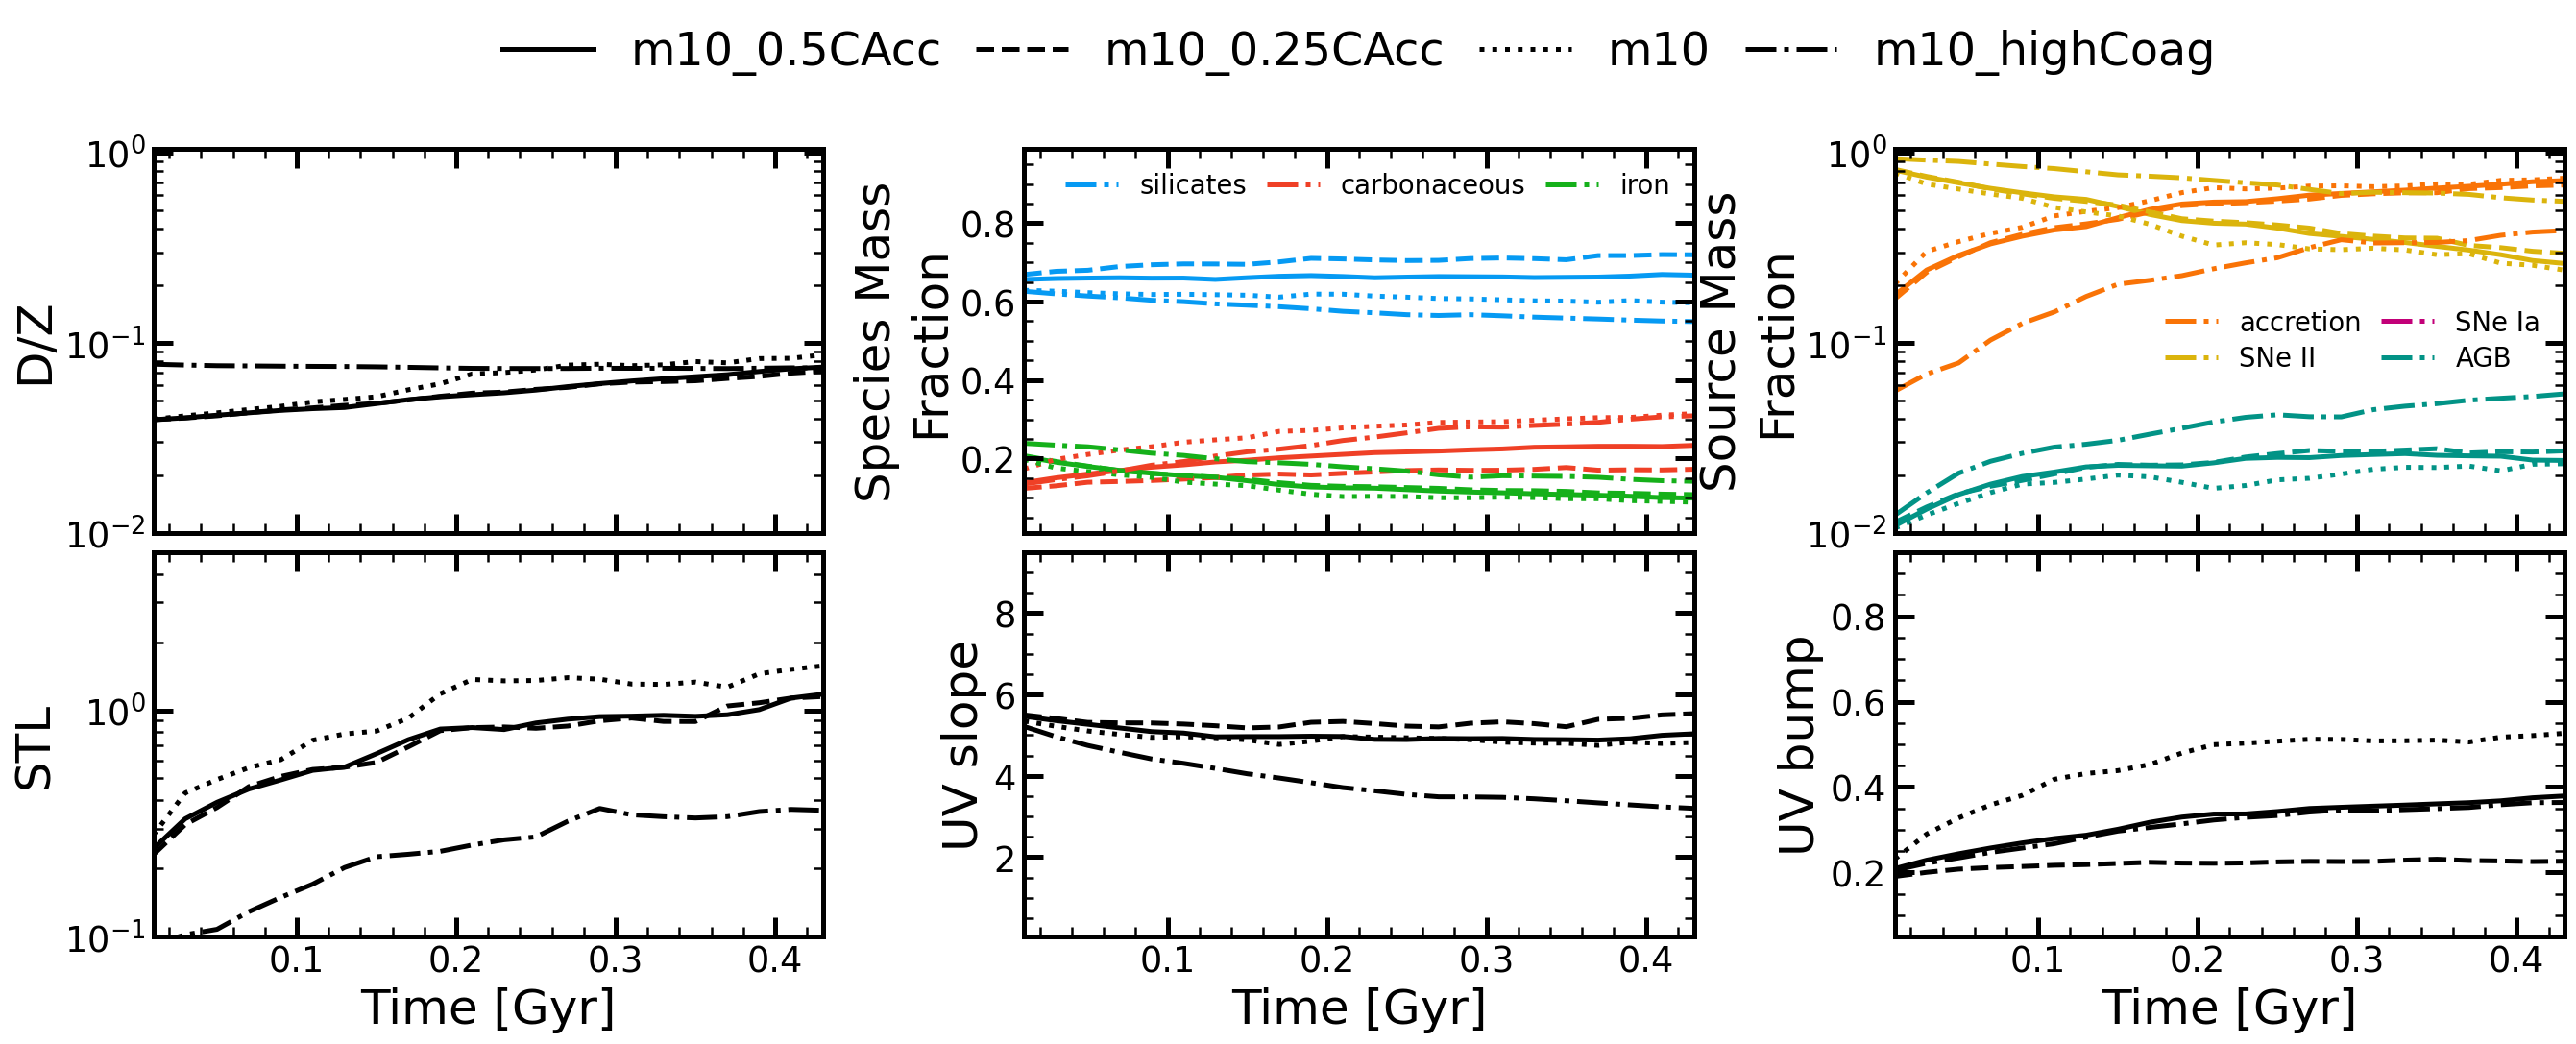

In [18]:

foutname = 'all_group_dust_evolution.pdf'

linestyles = config.LINE_STYLES
secondary_colors = config.LINE_COLORS
primary_colors = config.MARKER_COLORS


fig = Figure(6, sharex='col',ncols=3, yx_ratio=0.7)

for k,snap_dir in enumerate(snap_dirs):

    snap_nums = np.arange(start_snap_nums[k],end_snap_nums[k],2)
    sim_name = sim_names[k]
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums, include_extinction=True,gas_subsamples=['all'])
    time_evo_buffer.set_halo(mode='dense_gas', disk_rmax=disk_radii[k], disk_height=disk_scale_heights[k])
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

    time = time_evo_buffer.get_data('time', snap_nums = snap_nums)
    time -= (start_snap_nums[k]-1)*0.01 # recenter time axis so it represents time since start of simulation
    time_limits = [np.min(time),np.max(time)]

    

    i=0
    subsamples = ['cold','warm','hot']
    sample_labels = [r'$T < 10^3 \, K$',r'$10^3 \, K < T < 10^4 \, K$',r'$T > 10^4 \, K$']


    fig.set_axis(i, 'time', 'D/Z', x_lim=time_limits,x_log=False,twin_time_axis=False)
    subsample='all'
    DZ = time_evo_buffer.get_data('D/Z', subsample=subsample, snap_nums = snap_nums)
    fig.plot_line_data(i,time,DZ, color='xkcd:black',linestyle=linestyles[k], label=sim_name)


    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_sil = time_evo_buffer.get_data('M_sil', subsample='all', snap_nums = snap_nums)
    M_dust_carb = time_evo_buffer.get_data('M_carb', subsample='all', snap_nums = snap_nums)
    M_dust_iron = time_evo_buffer.get_data('M_iron', subsample='all', snap_nums = snap_nums)

    fig.set_axis(i, 'time', 'spec_frac', x_lim=time_limits,x_log=False,twin_time_axis=False, y_lim=[0.01,0.99])
    fig.plot_line_data(i,time,M_dust_sil/M_dust_total, color=secondary_colors[0],linestyle=linestyles[k], label='silicates')
    fig.plot_line_data(i,time,M_dust_carb/M_dust_total, color=secondary_colors[1],linestyle=linestyles[k], label='carbonaceous')
    fig.plot_line_data(i,time,M_dust_iron/M_dust_total, color=secondary_colors[2],linestyle=linestyles[k], label='iron')
    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=3)

    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_acc = time_evo_buffer.get_data('M_acc_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeII = time_evo_buffer.get_data('M_SNeII_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeIa = time_evo_buffer.get_data('M_SNeIa_dust', subsample='all', snap_nums = snap_nums)
    M_dust_AGB = time_evo_buffer.get_data('M_AGB_dust', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'source_frac', x_lim=time_limits,x_log=False,twin_time_axis=False)
    fig.plot_line_data(i,time,M_dust_acc/M_dust_total, color=primary_colors[0],linestyle=linestyles[k], label='accretion')
    fig.plot_line_data(i,time,M_dust_SNeII/M_dust_total, color=primary_colors[1],linestyle=linestyles[k], label='SNe II')
    fig.plot_line_data(i,time,M_dust_SNeIa/M_dust_total, color=primary_colors[2],linestyle=linestyles[k], label='SNe Ia')
    fig.plot_line_data(i,time,M_dust_AGB/M_dust_total, color=primary_colors[3],linestyle=linestyles[k], label='AGB')

    
    fig.set_axis_legend(i,loc='best',rescale_font=0.75,ncol=2)

    i+=1

    y_lim = [0.1,5]
    M_grain_small = time_evo_buffer.get_data('M_grain_small', subsample='all', snap_nums = snap_nums)
    M_grain_large = time_evo_buffer.get_data('M_grain_large', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'f_STL', x_lim=time_limits,x_log=False,y_lim=y_lim, twin_time_axis=False)
    fig.plot_line_data(i,time,M_grain_small/M_grain_large, color='xkcd:black',linestyle=linestyles[k])



    extinction = time_evo_buffer.get_data('extinction', subsample='all')
    extinction_wavelengths = extinction[0]
    extinction_curves = extinction[1]
    slopes = np.zeros(len(extinction_curves)); bumps = np.zeros(len(extinction_curves))
    for j in range(len(extinction_curves)):
        slopes[j], bumps[j] = grain_size_utils.calculate_extinction_parameters(extinction_wavelengths[j],extinction_curves[j])

    i+=1
    y_lim = [0.05,9.5]
    fig.set_axis(i, 'time', 'S', x_lim=time_limits,x_log=False,y_lim=y_lim, y_log=False, y_label='UV slope', twin_time_axis=False)
    fig.plot_line_data(i,time,slopes, color='xkcd:black',linestyle=linestyles[k])

    i+=1
    y_lim = [0.05,0.95]
    fig.set_axis(i, 'time', 'B', x_lim=time_limits,x_log=False,y_lim=y_lim, y_log=False, y_label='UV bump', twin_time_axis=False)
    fig.plot_line_data(i,time,bumps, color='xkcd:black',linestyle=linestyles[k])

fig.set_outside_legend(rescale_font=1.3,ncol=4)

fig.save(plot_dir+foutname)



Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....
Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....


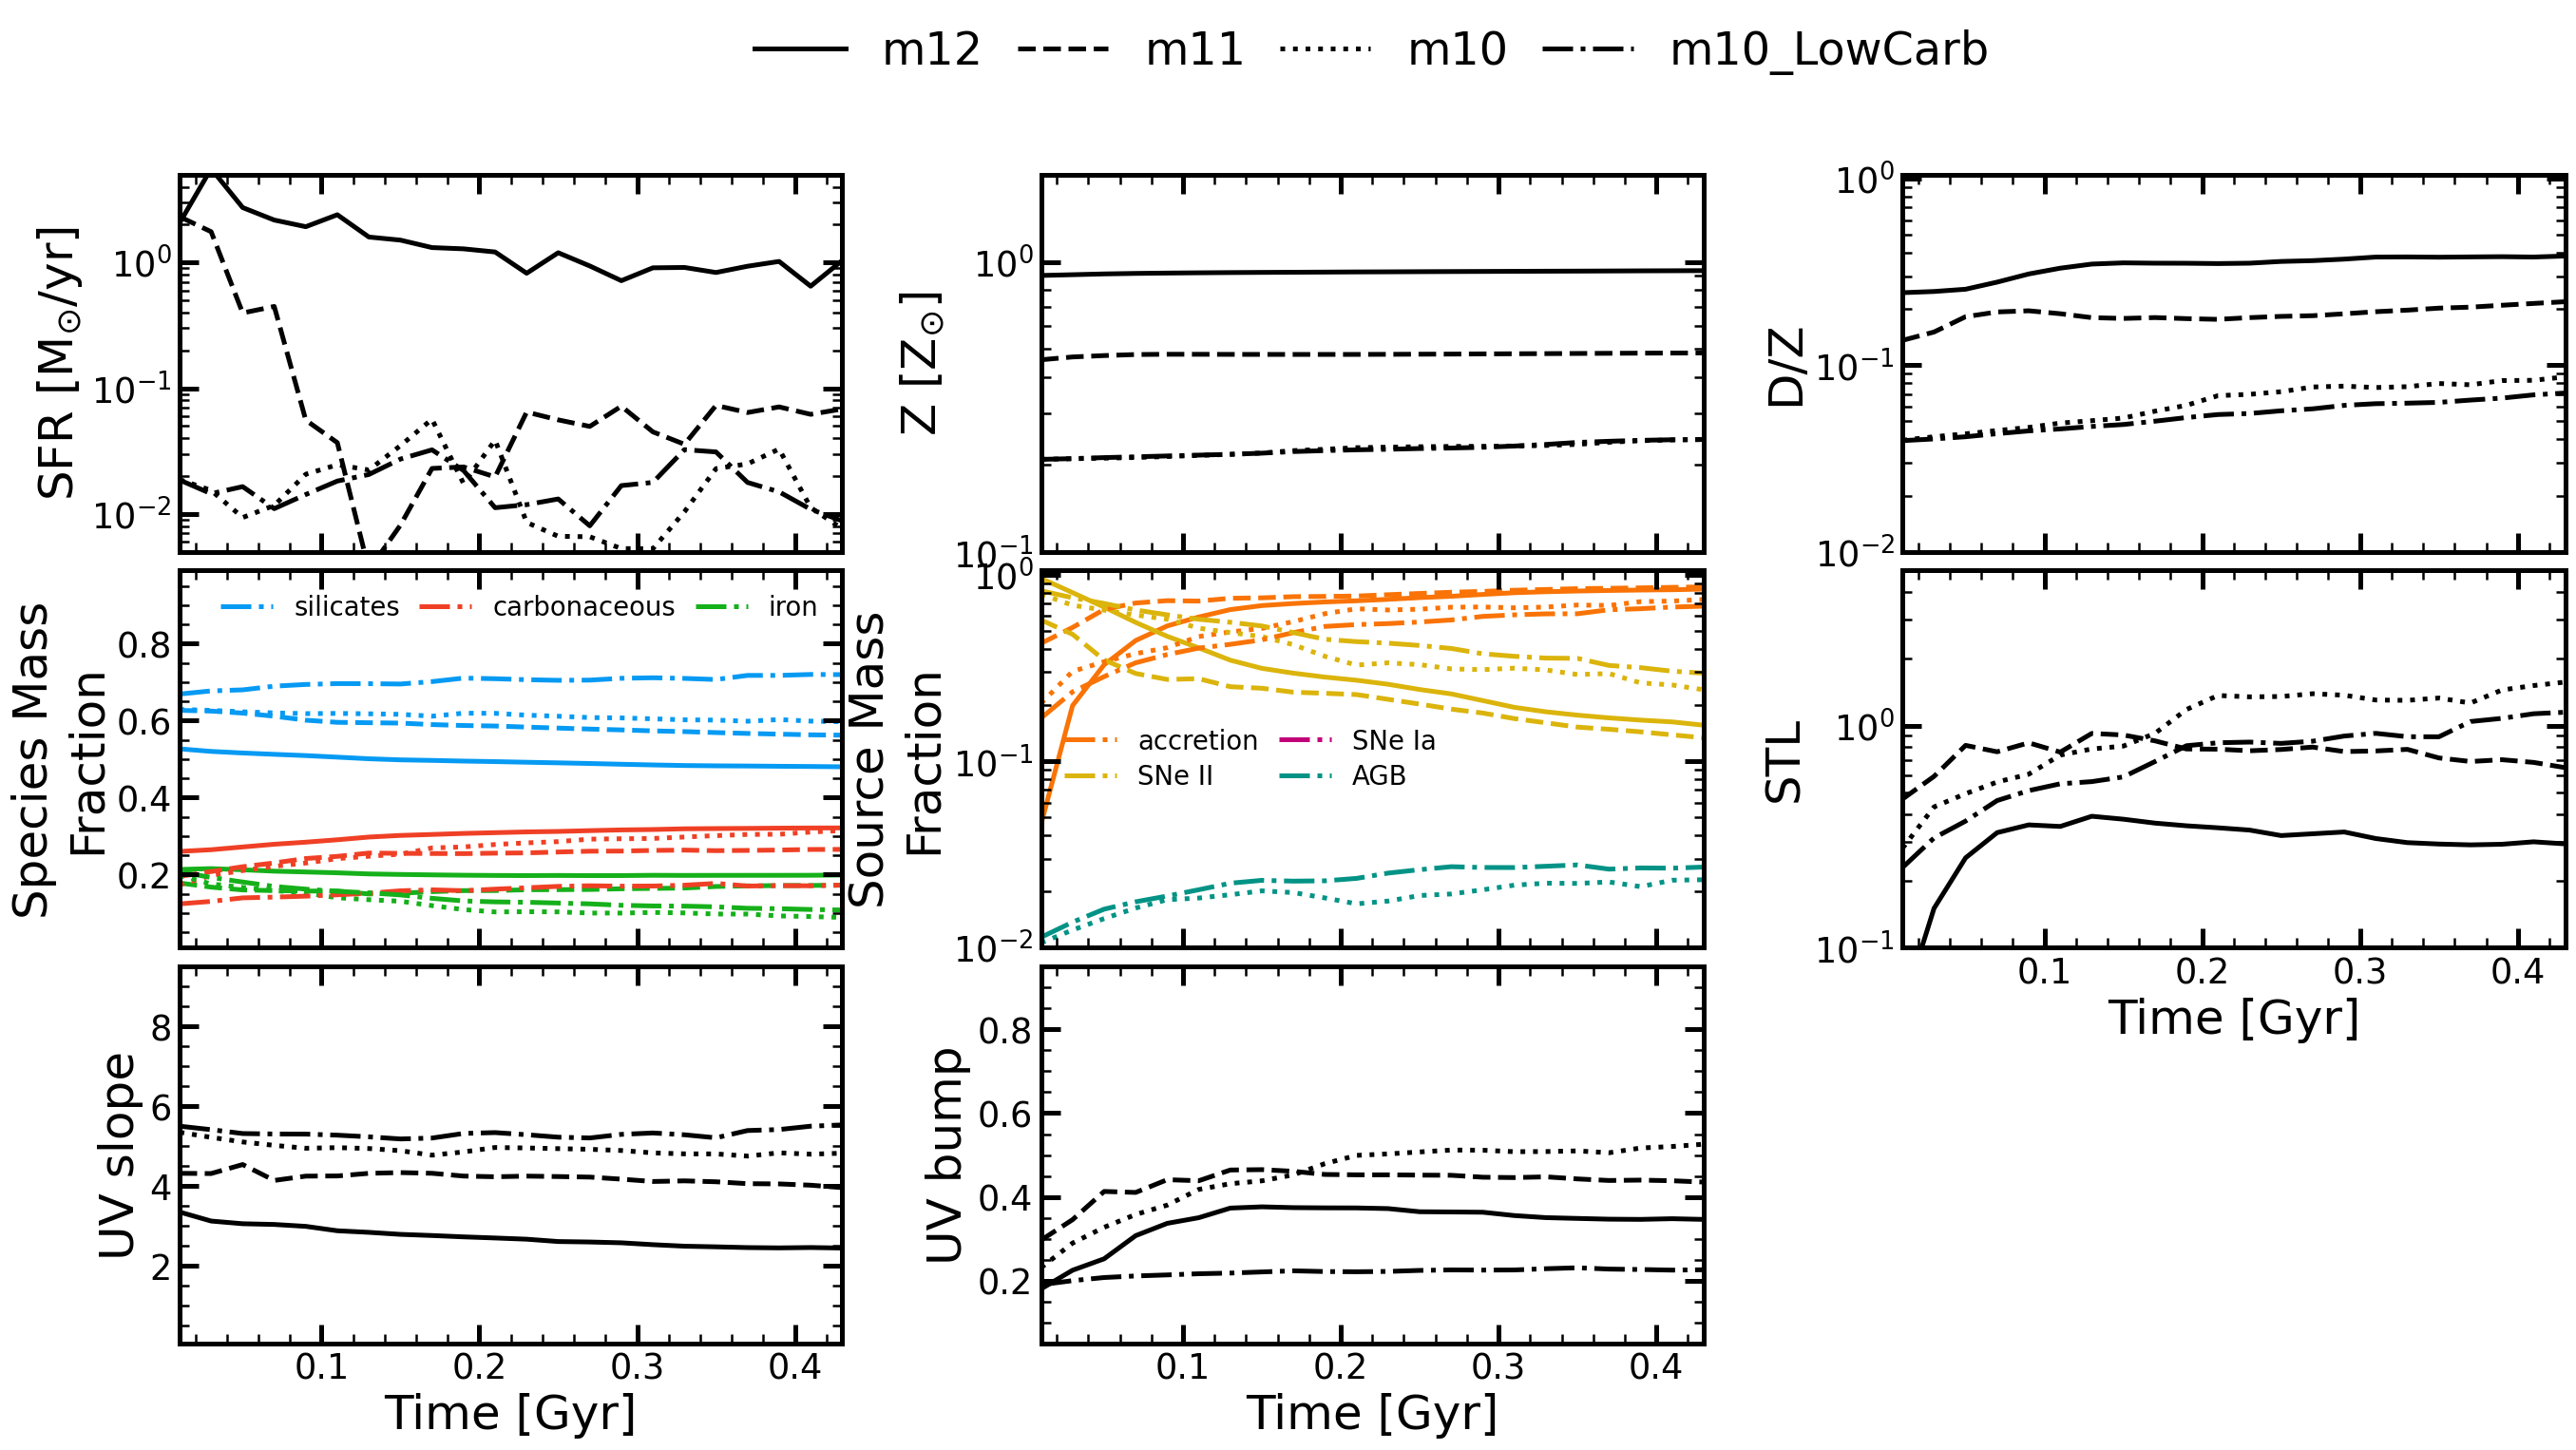

In [25]:

foutname = 'all_group_dust_evolution.pdf'

linestyles = config.LINE_STYLES
secondary_colors = config.LINE_COLORS
primary_colors = config.MARKER_COLORS


fig = Figure(8, sharex='col',ncols=3, yx_ratio=0.7)

for k,snap_dir in enumerate(snap_dirs):

    snap_nums = np.arange(start_snap_nums[k],end_snap_nums[k],2)
    sim_name = sim_names[k]
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums, include_extinction=True,gas_subsamples=['all'])
    time_evo_buffer.set_halo(mode='dense_gas', disk_rmax=disk_radii[k], disk_height=disk_scale_heights[k])
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

    time = time_evo_buffer.get_data('time', snap_nums = snap_nums)
    time -= (start_snap_nums[k]-1)*0.01 # recenter time axis so it represents time since start of simulation
    time_limits = [np.min(time),np.max(time)]

    

    i=0
    fig.set_axis(i, 'time', 'sfr', x_lim=time_limits,x_log=False,twin_time_axis=False, y_lim=[5E-3,5])
    subsample='all'
    sfr = time_evo_buffer.get_data('sfr', subsample='all', snap_nums = snap_nums)
    fig.plot_line_data(i,time,sfr, color='xkcd:black',linestyle=linestyles[k], label=sim_name)


    i+=1

    fig.set_axis(i, 'time', 'Z', x_lim=time_limits,x_log=False,twin_time_axis=False, y_lim=[0.1,2])
    subsample='all'
    Z = time_evo_buffer.get_data('Z', subsample='all', snap_nums = snap_nums)
    fig.plot_line_data(i,time,Z, color='xkcd:black',linestyle=linestyles[k], label=sim_name)


    i+=1


    fig.set_axis(i, 'time', 'D/Z', x_lim=time_limits,x_log=False,twin_time_axis=False)
    subsample='all'
    DZ = time_evo_buffer.get_data('D/Z', subsample=subsample, snap_nums = snap_nums)
    fig.plot_line_data(i,time,DZ, color='xkcd:black',linestyle=linestyles[k], label=sim_name)


    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_sil = time_evo_buffer.get_data('M_sil', subsample='all', snap_nums = snap_nums)
    M_dust_carb = time_evo_buffer.get_data('M_carb', subsample='all', snap_nums = snap_nums)
    M_dust_iron = time_evo_buffer.get_data('M_iron', subsample='all', snap_nums = snap_nums)

    fig.set_axis(i, 'time', 'spec_frac', x_lim=time_limits,x_log=False,twin_time_axis=False, y_lim=[0.01,0.99])
    fig.plot_line_data(i,time,M_dust_sil/M_dust_total, color=secondary_colors[0],linestyle=linestyles[k], label='silicates')
    fig.plot_line_data(i,time,M_dust_carb/M_dust_total, color=secondary_colors[1],linestyle=linestyles[k], label='carbonaceous')
    fig.plot_line_data(i,time,M_dust_iron/M_dust_total, color=secondary_colors[2],linestyle=linestyles[k], label='iron')
    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=3)

    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_acc = time_evo_buffer.get_data('M_acc_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeII = time_evo_buffer.get_data('M_SNeII_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeIa = time_evo_buffer.get_data('M_SNeIa_dust', subsample='all', snap_nums = snap_nums)
    M_dust_AGB = time_evo_buffer.get_data('M_AGB_dust', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'source_frac', x_lim=time_limits,x_log=False,twin_time_axis=False)
    fig.plot_line_data(i,time,M_dust_acc/M_dust_total, color=primary_colors[0],linestyle=linestyles[k], label='accretion')
    fig.plot_line_data(i,time,M_dust_SNeII/M_dust_total, color=primary_colors[1],linestyle=linestyles[k], label='SNe II')
    fig.plot_line_data(i,time,M_dust_SNeIa/M_dust_total, color=primary_colors[2],linestyle=linestyles[k], label='SNe Ia')
    fig.plot_line_data(i,time,M_dust_AGB/M_dust_total, color=primary_colors[3],linestyle=linestyles[k], label='AGB')

    
    fig.set_axis_legend(i,loc='best',rescale_font=0.75,ncol=2)

    i+=1

    y_lim = [0.1,5]
    M_grain_small = time_evo_buffer.get_data('M_grain_small', subsample='all', snap_nums = snap_nums)
    M_grain_large = time_evo_buffer.get_data('M_grain_large', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'f_STL', x_lim=time_limits,x_log=False,y_lim=y_lim, twin_time_axis=False)
    fig.plot_line_data(i,time,M_grain_small/M_grain_large, color='xkcd:black',linestyle=linestyles[k])



    extinction = time_evo_buffer.get_data('extinction', subsample='all')
    extinction_wavelengths = extinction[0]
    extinction_curves = extinction[1]
    slopes = np.zeros(len(extinction_curves)); bumps = np.zeros(len(extinction_curves))
    for j in range(len(extinction_curves)):
        slopes[j], bumps[j] = grain_size_utils.calculate_extinction_parameters(extinction_wavelengths[j],extinction_curves[j])

    i+=1
    y_lim = [0.05,9.5]
    fig.set_axis(i, 'time', 'S', x_lim=time_limits,x_log=False,y_lim=y_lim, y_log=False, y_label='UV slope', twin_time_axis=False)
    fig.plot_line_data(i,time,slopes, color='xkcd:black',linestyle=linestyles[k])

    i+=1
    y_lim = [0.05,0.95]
    fig.set_axis(i, 'time', 'B', x_lim=time_limits,x_log=False,y_lim=y_lim, y_log=False, y_label='UV bump', twin_time_axis=False)
    fig.plot_line_data(i,time,bumps, color='xkcd:black',linestyle=linestyles[k])

fig.set_outside_legend(rescale_font=1.3,ncol=4)

fig.save(plot_dir+foutname)

